# Heat Stress Mapping of Indian Metro Cities

## Project overview

This notebook analyzes daily NASA POWER/MERRA-2 weather data for Ahmedabad, Bengaluru, Chennai, Delhi, Kolkata, and Mumbai from 2010–2025. It uses the humidity-adjusted National Weather Service (NWS) Heat Index to characterize heat-stress exposure. Temperature alone misses how humidity can limit evaporative cooling and make conditions more stressful for people.

This distinction matters especially when comparing hot, dry conditions with warm, humid conditions across cities.

### Objectives

- Calculate and categorize the daily Heat Index.
- Compare temperature-only hot days with humidity-adjusted heat stress.
- Identify seasonal, monthly, and annual patterns.
- Rank cities by the percentage of Danger or Extreme Danger days.


## 1. Imports and data loading


In [1]:
import pandas as pd
import numpy as np
import calendar
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
cities = ['Chennai', 'Delhi', 'Mumbai', 'Kolkata', 'Bengaluru', 'Ahmedabad']
dataframes = []

for city in cities:
    file_path = f"../dataset/raw_datasets/{city}.csv"
    temp_df = pd.read_csv(file_path, skiprows=16)
    temp_df['city'] = city
    dataframes.append(temp_df)

df = pd.concat(dataframes, ignore_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         35064 non-null  int64  
 1   DOY          35064 non-null  int64  
 2   RH2M         35064 non-null  float64
 3   T2M          35064 non-null  float64
 4   T2MDEW       35064 non-null  float64
 5   T2M_MAX      35064 non-null  float64
 6   T2M_MIN      35064 non-null  float64
 7   T2MWET       35064 non-null  float64
 8   WS2M         35064 non-null  float64
 9   PRECTOTCORR  35064 non-null  float64
 10  city         35064 non-null  object 
dtypes: float64(8), int64(2), object(1)
memory usage: 2.9+ MB


In [3]:
display(df.head())
print('Dataset shape:', df.shape)
print('Cities:', ', '.join(df['city'].unique()))

,YEAR,DOY,RH2M,T2M,T2MDEW,T2M_MAX,T2M_MIN,T2MWET,WS2M,PRECTOTCORR,city
0,2010,1,81.89,24.14,20.75,27.83,21.54,22.45,2.96,0.00,Chennai
1,2010,2,81.10,23.77,20.24,26.94,21.18,22.01,3.25,0.01,Chennai
2,2010,3,79.15,23.32,19.43,26.58,20.84,21.37,3.03,0.01,Chennai
3,2010,4,77.30,22.86,18.57,26.46,20.49,20.72,2.10,0.00,Chennai
4,2010,5,79.50,22.83,18.99,26.80,19.15,20.91,2.01,0.00,Chennai


Dataset shape: (35064, 11)
Cities: Chennai, Delhi, Mumbai, Kolkata, Bengaluru, Ahmedabad


## 2. Data preparation and validation

Only fields used in the analysis are retained. Wet-bulb temperature (T2MWET) is kept as an independent cross-check of the Heat Index.


In [4]:
df = df.rename(columns={
    'YEAR': 'year',
    'DOY': 'day_of_year',
    'T2M': 'temperature',
    'T2M_MAX': 'max_temperature',
    'RH2M': 'humidity',
    'T2MWET': 'wet_bulb_temperature'
})

df = df.drop(columns=['T2M_MIN', 'T2MDEW', 'WS2M', 'PRECTOTCORR'], errors='ignore')

In [5]:
df['date'] = pd.to_datetime(
    df['year'].astype(str) + df['day_of_year'].astype(str), format='%Y%j'
)

date_summary = (
    df.groupby('city')['date']
      .agg(first_date='min', last_date='max', records='count')
      .reset_index()
)

duplicate_records = df.duplicated(subset=['city', 'year', 'day_of_year']).sum()
invalid_values = (df == -999).sum().sum()
print(f'City/year/day duplicates: {duplicate_records}')
print(f'Total -999 values: {invalid_values}')
date_summary

City/year/day duplicates: 0
Total -999 values: 0


,city,first_date,last_date,records
0,Ahmedabad,2010-01-01,2025-12-31,5844
1,Bengaluru,2010-01-01,2025-12-31,5844
2,Chennai,2010-01-01,2025-12-31,5844
3,Delhi,2010-01-01,2025-12-31,5844
4,Kolkata,2010-01-01,2025-12-31,5844
5,Mumbai,2010-01-01,2025-12-31,5844


In [6]:
df["month"] = df["date"].dt.month

In [7]:
def set_season(month):
    if month in [3, 4, 5, 6]:
        return "Summer"
    elif month in [7, 8, 9]:
        return "Monsoon"
    elif month in [10, 11]:
        return "Post-Monsoon"
    else:
        return "Winter"

df['season'] = df['month'].apply(set_season)

*Season definition note:* Summer is defined as March–June and Monsoon as July–September, a simplification; actual monsoon onset varies by city.


## 3. Exploratory temperature and humidity patterns


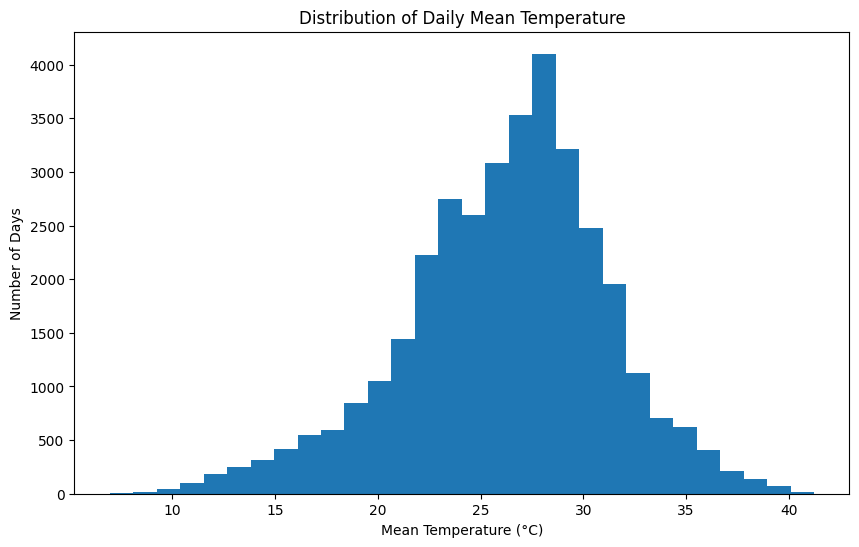

In [8]:
plt.figure(figsize=(10, 6))

plt.hist(df["temperature"].dropna(), bins=30)

plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Number of Days")
plt.title("Distribution of Daily Mean Temperature")

plt.show()

*Figure note:* This distribution summarizes daily mean air temperature across all six cities and study years.


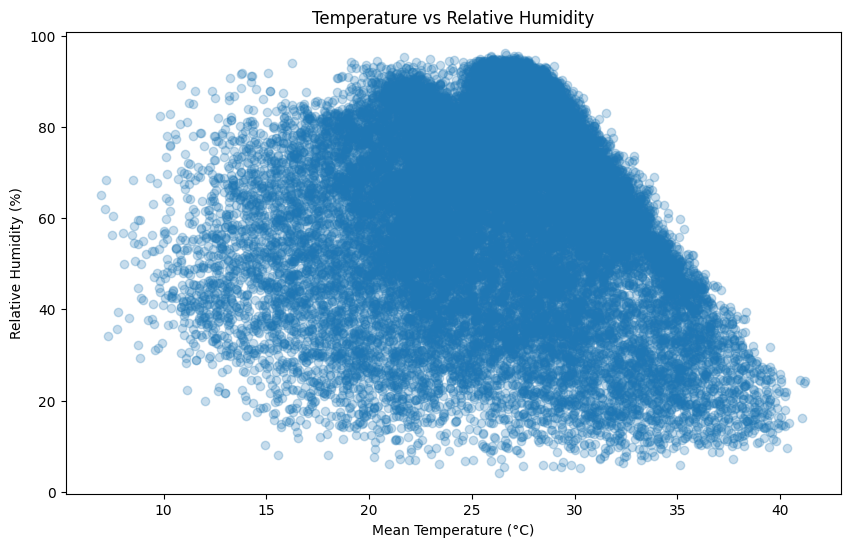

In [9]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["temperature"],
    df["humidity"],
    alpha=0.25
)

plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.title("Temperature vs Relative Humidity")

plt.show()

*Figure note:* The scatterplot shows the humidity context that makes temperature-only assessments incomplete.


## 4. NWS Heat Index calculation

The function below implements the supplied NWS-compatible method: it uses the Rothfusz regression only when the NWS threshold is met, and constrains humidity adjustments to their valid ranges.


In [10]:
def heat_index_c(temperature, humidity):
    t = np.asarray(temperature, dtype=float) * 9 / 5 + 32
    rh = np.asarray(humidity, dtype=float)

    simple = 0.5 * (t + 61.0 + (t - 68.0) * 1.2 + rh * 0.094)

    rothfusz = (-42.379 + 2.04901523*t + 10.14333127*rh
                - 0.22475541*t*rh - 0.00683783*t**2 - 0.05481717*rh**2
                + 0.00122874*t**2*rh + 0.00085282*t*rh**2
                - 0.00000199*t**2*rh**2)

    # Adjustments apply only to the Rothfusz result, in their valid ranges
    low = (rh < 13) & (t >= 80) & (t <= 112)
    rothfusz = np.where(low, rothfusz - ((13 - rh) / 4)
                        * np.sqrt(np.clip((17 - np.abs(t - 95)) / 17, 0, None)), rothfusz)
    high = (rh > 85) & (t >= 80) & (t <= 87)
    rothfusz = np.where(high, rothfusz + ((rh - 85) / 10) * ((87 - t) / 5), rothfusz)

    # NWS rule: Rothfusz only if the average of simple and T is >= 80°F
    hi_f = np.where((simple + t) / 2 >= 80, rothfusz, simple)
    return (hi_f - 32) * 5 / 9

In [11]:
test_data = pd.DataFrame({
    "temperature_c": [25, 30, 32, 35, 38],
    "humidity": [50, 60, 70, 60, 20]
})

test_data["heat_index_c"] = heat_index_c(
    test_data["temperature_c"], test_data["humidity"]
)
test_data

,temperature_c,humidity,heat_index_c
0,25,50,24.861111
1,30,60,32.832032
2,32,70,40.409274
3,35,60,45.050171
4,38,20,36.661090


In [12]:
df["heat_index"] = heat_index_c(df["temperature"], df["humidity"]).round(2)
df["heat_index"].describe()

count    35064.000000
mean        27.985047
std          6.764757
min          5.000000
25%         23.397500
50%         28.130000
75%         33.410000
max         45.850000
Name: heat_index, dtype: float64

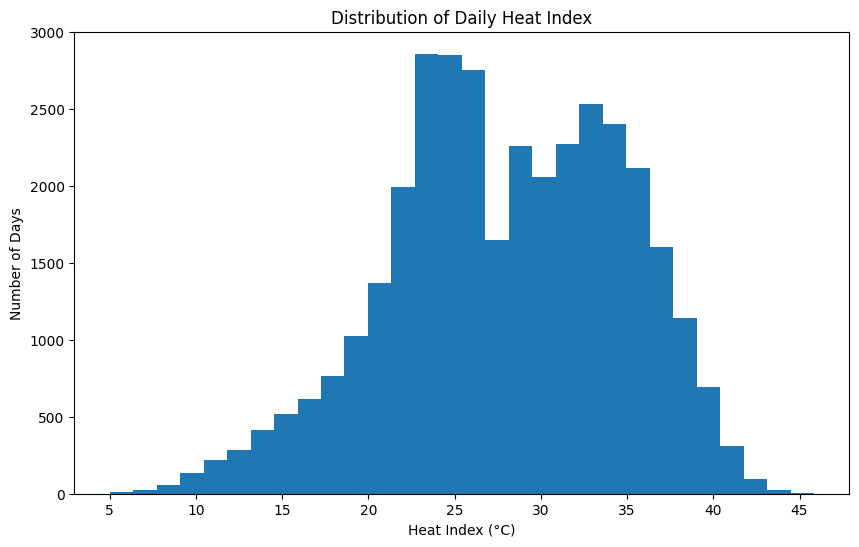

In [13]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["heat_index"].dropna(),
    bins=30
)

plt.xlabel("Heat Index (°C)")
plt.ylabel("Number of Days")
plt.title("Distribution of Daily Heat Index")

plt.show()

*Figure note:* This is the distribution of recalculated daily Heat Index values used in all downstream tables and charts.


In [14]:
bins = [-np.inf, 26.7, 32.2, 39.4, 51.7, np.inf]
labels = ["Safe", "Caution", "Extreme Caution", "Danger", "Extreme Danger"]

df["hi_category"] = pd.cut(
    df["heat_index"],
    bins=bins,
    labels=labels,
    right=False
)

In [15]:
category_counts = df['hi_category'].value_counts().reindex(labels)
category_counts

hi_category
Safe               15669
Caution             8396
Extreme Caution    10084
Danger               915
Extreme Danger         0
Name: count, dtype: int64

In [16]:
df.groupby('hi_category', observed=True)['heat_index'].agg(['min', 'max'])

,min,max
hi_category,,
Safe,5.0,26.69
Caution,26.7,32.19
Extreme Caution,32.2,39.39
Danger,39.4,45.85


## 5. City and seasonal heat-stress patterns

Tables precede their related charts so the plotted patterns can be checked directly.


In [17]:
category_pct = (
    df.groupby(['city', 'hi_category'], observed=True)
      .size()
      .groupby(level=0, group_keys=False)
      .apply(lambda x: x / x.sum() * 100)
      .unstack(fill_value=0)
      .reindex(columns=labels, fill_value=0)
      .round(2)
)
category_pct

hi_category,Safe,Caution,Extreme Caution,Danger,Extreme Danger
city,,,,,
Ahmedabad,37.97,25.70,32.36,3.97,0
Bengaluru,81.57,18.16,0.27,0.00,0
Chennai,25.33,28.80,44.58,1.30,0
Delhi,49.14,16.44,29.93,4.48,0
Kolkata,38.26,11.74,44.27,5.73,0
Mumbai,35.85,42.83,21.15,0.17,0


In [18]:
city_summary = (
    df.groupby('city', observed=True)
      .agg(
          mean_hi=('heat_index', 'mean'),
          max_hi=('heat_index', 'max'),
          danger_pct=('hi_category', lambda x: x.isin(['Danger', 'Extreme Danger']).mean() * 100)
      )
      .sort_values('danger_pct', ascending=False)
      .round(2)
)
city_summary


,mean_hi,max_hi,danger_pct
city,,,
Kolkata,29.30,45.85,5.73
Delhi,26.05,44.23,4.48
Ahmedabad,28.81,43.05,3.97
Chennai,31.06,42.79,1.30
Mumbai,28.51,41.87,0.17
Bengaluru,24.18,33.60,0.00


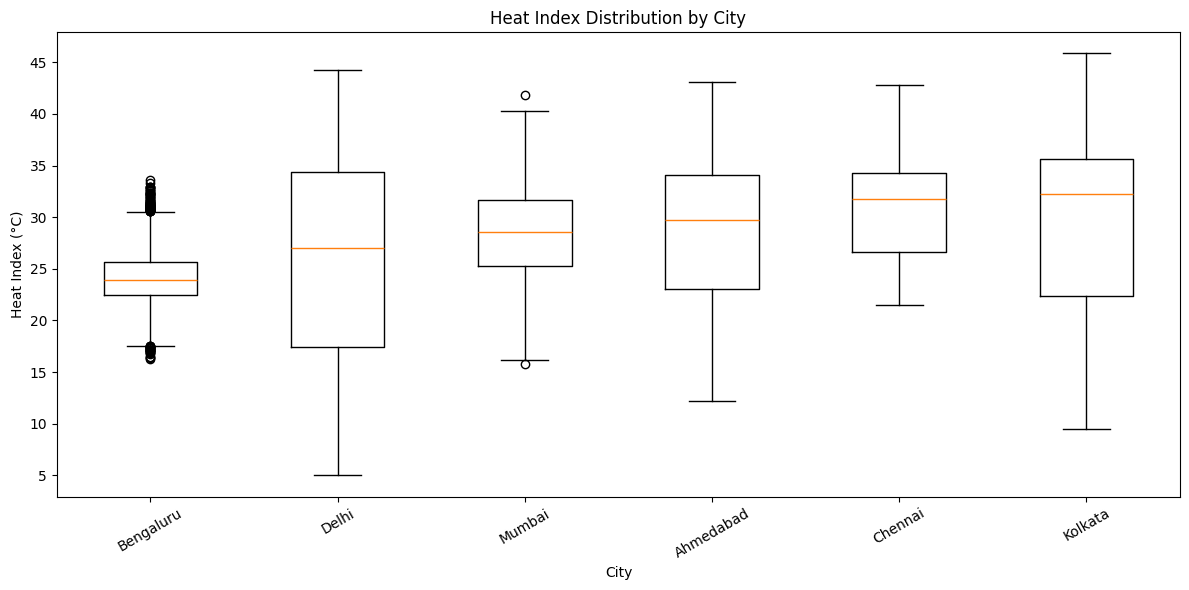

In [19]:
city_order = (
    df.groupby("city", observed=True)["heat_index"]
      .median()
      .sort_values()
      .index
)

plt.figure(figsize=(12, 6))

data = [
    df.loc[df["city"] == city, "heat_index"].dropna()
    for city in city_order
]

plt.boxplot(
    data,
    tick_labels=city_order
)

plt.xlabel("City")
plt.ylabel("Heat Index (°C)")
plt.title("Heat Index Distribution by City")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

*Figure note:* The boxplot compares the full distribution of daily Heat Index values by city; city ranking is based on Danger or Extreme Danger day share, not annual mean Heat Index.


In [20]:
monthly_heatmap = (
    df.groupby(['city', 'month'], observed=True)["heat_index"]
    .mean()
    .unstack()
    .round(2)
)

monthly_heatmap

month,1,2,3,4,5,6,7,8,9,10,11,12
city,,,,,,,,,,,,
Ahmedabad,18.52,22.43,27.01,31.56,36.52,38.46,35.34,32.74,31.66,28.25,23.49,19.50
Bengaluru,21.05,23.21,26.58,28.81,27.95,24.93,24.09,24.02,23.70,23.20,21.85,20.81
Chennai,24.70,26.21,30.97,35.53,37.17,34.99,33.57,33.10,32.21,30.89,27.74,25.41
Delhi,11.76,16.02,22.66,28.91,33.38,37.60,37.91,35.19,31.27,25.06,18.92,13.40
Kolkata,16.95,21.75,28.48,35.35,37.92,37.73,35.86,34.78,33.52,29.07,22.24,17.61
Mumbai,22.66,25.30,28.84,32.92,35.56,33.76,29.80,28.17,28.33,28.58,25.06,23.11


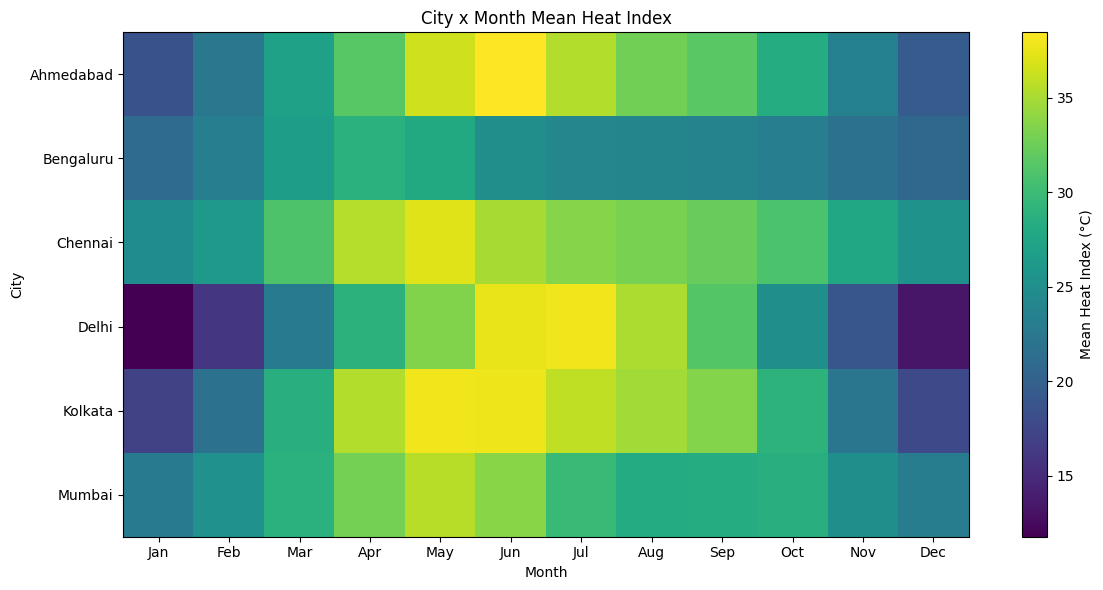

In [21]:
plt.figure(figsize=(12, 6))

plt.imshow(
    monthly_heatmap,
    aspect="auto"
)

plt.colorbar(label="Mean Heat Index (°C)")

plt.xticks(
    range(12),
    [calendar.month_abbr[i] for i in range(1, 13)]
)

plt.yticks(
    range(len(monthly_heatmap.index)),
    monthly_heatmap.index
)

plt.xlabel("Month")
plt.ylabel("City")
plt.title("City x Month Mean Heat Index")

plt.tight_layout()
plt.show()

*Figure note:* Each cell is the mean daily Heat Index for the specified city and calendar month.


## 6. Hot-day analysis and humidity-adjusted risk

A hot day is defined here as a day with maximum air temperature of at least 40°C. It is distinct from a heatwave, which requires a duration-based definition not applied in this notebook.


In [22]:
df["hot_day"] = df["max_temperature"] >= 40

annual_hot_days = (
    df.groupby(
        ["city", "year"]
    )["hot_day"]
    .sum()
    .reset_index(name="hot_days")
)

annual_hot_days.head()

,city,year,hot_days
0,Ahmedabad,2010,95
1,Ahmedabad,2011,88
2,Ahmedabad,2012,81
3,Ahmedabad,2013,49
4,Ahmedabad,2014,96


In [23]:
hot_day_summary = (
    df.groupby("city")
      .agg(
          hot_days=("hot_day", "sum"),
          total_days=("hot_day", "size")
      )
      .reset_index()
)

hot_day_summary["hot_day_pct"] = (
    hot_day_summary["hot_days"]
    / hot_day_summary["total_days"]
    * 100
).round(2)

In [24]:
danger_days = (
    df.groupby('city', observed=True)['hi_category']
      .apply(lambda x: x.isin(['Danger', 'Extreme Danger']).mean() * 100)
      .rename('danger_days_pct')
      .reset_index()
)

comparison = (
    hot_day_summary[['city', 'hot_days', 'hot_day_pct']]
    .merge(danger_days, on='city', how='left')
)
comparison['temperature_rank'] = comparison['hot_day_pct'].rank(method='min', ascending=False).astype(int)
comparison['heat_index_rank'] = comparison['danger_days_pct'].rank(method='min', ascending=False).astype(int)
comparison = comparison.sort_values('heat_index_rank').reset_index(drop=True)
comparison

,city,hot_days,hot_day_pct,danger_days_pct,temperature_rank,heat_index_rank
0,Kolkata,303,5.18,5.732375,4,1
1,Delhi,1031,17.64,4.483231,2,2
2,Ahmedabad,1212,20.74,3.969884,1,3
3,Chennai,33,0.56,1.300479,5,4
4,Mumbai,378,6.47,0.171116,3,5
5,Bengaluru,5,0.09,0.000000,6,6


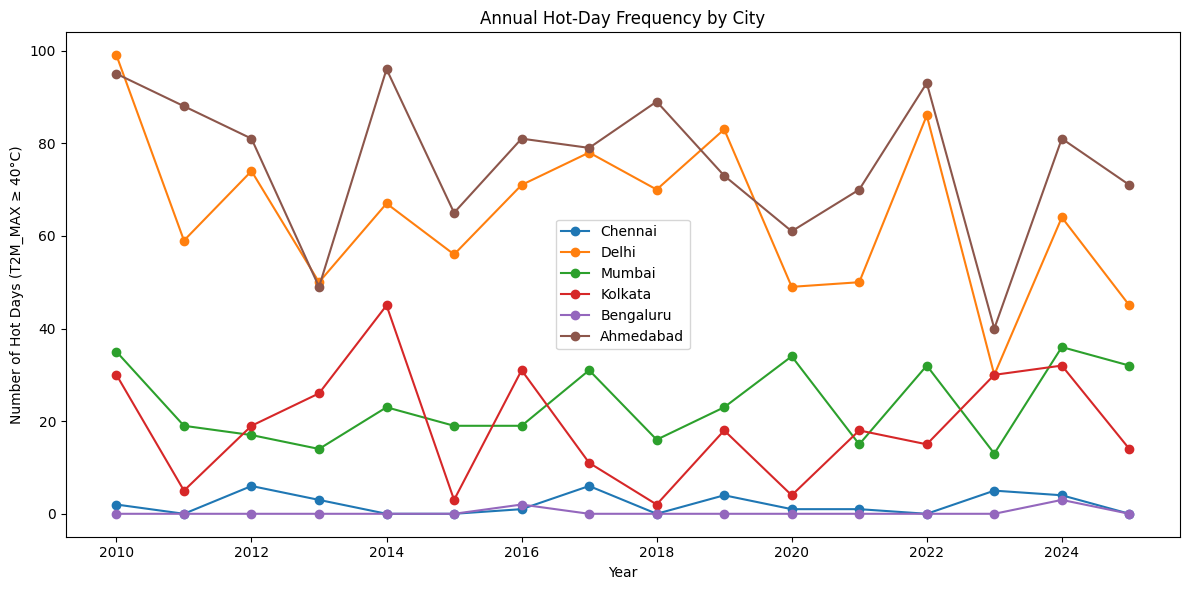

In [25]:
plt.figure(figsize=(12, 6))

for city in cities:
    city_data = annual_hot_days[
        annual_hot_days["city"] == city
    ]

    plt.plot(
        city_data["year"],
        city_data["hot_days"],
        marker="o",
        label=city
    )

plt.xlabel("Year")
plt.ylabel("Number of Hot Days (T2M_MAX ≥ 40°C)")
plt.title("Annual Hot-Day Frequency by City")

plt.legend()

plt.tight_layout()
plt.show()

*Figure note:* Annual counts show hot days, not heatwaves. The comparison table above contrasts this temperature-only measure with humidity-adjusted danger-day exposure.


## 7. Wet-bulb cross-check

T2MWET is used as a complementary moisture-and-temperature indicator; it does not replace the NWS Heat Index.


In [26]:
wetbulb_summary = (
    df.groupby("city")
      .agg(
          mean_heat_index=("heat_index", "mean"),
          mean_wet_bulb=("wet_bulb_temperature", "mean")
      )
      .round(2)
)

wetbulb_summary

,mean_heat_index,mean_wet_bulb
city,,
Ahmedabad,28.81,20.55
Bengaluru,24.18,20.00
Chennai,31.06,25.07
Delhi,26.05,18.33
Kolkata,29.30,22.99
Mumbai,28.51,22.91


In [27]:
hi_wetbulb_correlation = (
    df[["heat_index", "wet_bulb_temperature"]]
    .corr()
    .loc["heat_index", "wet_bulb_temperature"]
)

print(
    f"Correlation between Heat Index and Wet-Bulb Temperature: "
    f"{hi_wetbulb_correlation:.3f}"
)

Correlation between Heat Index and Wet-Bulb Temperature: 0.888


## 8. Annual trends

Trend tests cover 2010–2025. Statistical significance is assessed at α = 0.05; results should be described as no statistically significant trend where p ≥ 0.05.


In [28]:
annual_hi = (
    df.groupby(
        ["city", "year"]
    )["heat_index"]
    .mean()
    .reset_index(name="mean_heat_index")
    .round(2)
)

annual_hi.head()

,city,year,mean_heat_index
0,Ahmedabad,2010,29.25
1,Ahmedabad,2011,28.62
2,Ahmedabad,2012,28.65
3,Ahmedabad,2013,28.09
4,Ahmedabad,2014,28.60


In [29]:
trend_results = []

for city in cities:
    city_data = annual_hi[
        annual_hi["city"] == city
    ]

    trend = linregress(
        city_data["year"],
        city_data["mean_heat_index"]
    )

    trend_results.append({
        "city": city,
        "slope": trend.slope,
        "p_value": trend.pvalue,
        "r_squared": trend.rvalue ** 2,
        "significant": "Yes" if trend.pvalue < 0.05 else "No"
    })

trend_table = pd.DataFrame(trend_results)

trend_table

,city,slope,p_value,r_squared,significant
0,Chennai,0.039000,0.080869,0.201819,No
1,Delhi,0.031662,0.205044,0.112054,No
2,Mumbai,0.029162,0.288071,0.080130,No
3,Kolkata,0.031074,0.255859,0.091116,No
4,Bengaluru,0.011603,0.630575,0.016974,No
5,Ahmedabad,-0.003926,0.852805,0.002545,No


In [30]:
hot_day_trends = []

for city in cities:
    city_data = annual_hot_days[
        annual_hot_days["city"] == city
    ]

    trend = linregress(
        city_data["year"],
        city_data["hot_days"]
    )

    hot_day_trends.append({
        "city": city,
        "slope_hot_days_per_year": trend.slope,
        "p_value": trend.pvalue,
        "r_squared": trend.rvalue ** 2,
        "significant": "Yes" if trend.pvalue < 0.05 else "No"
    })

hot_day_trend_table = pd.DataFrame(hot_day_trends).round(4)

hot_day_trend_table

,city,slope_hot_days_per_year,p_value,r_squared,significant
0,Chennai,-0.0015,0.9909,0.0000,No
1,Delhi,-1.5162,0.1160,0.1670,No
2,Mumbai,0.4559,0.3275,0.0685,No
3,Kolkata,-0.1456,0.8387,0.0031,No
4,Bengaluru,0.0485,0.3220,0.0700,No
5,Ahmedabad,-1.0618,0.2362,0.0986,No


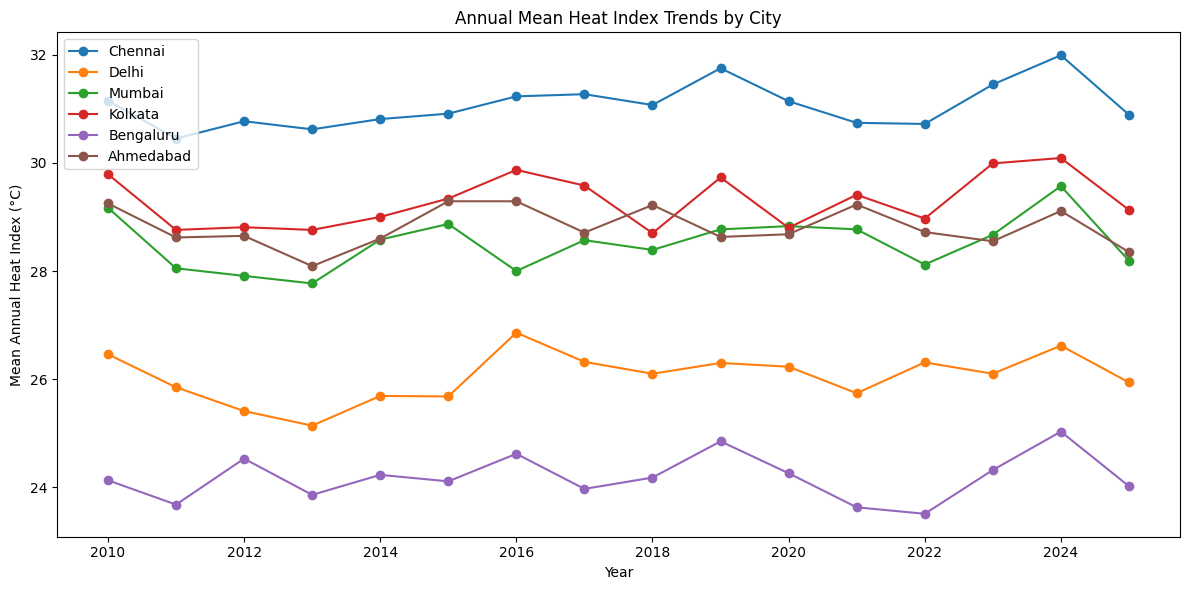

In [31]:
plt.figure(figsize=(12, 6))

for city in cities:
    city_data = annual_hi[
        annual_hi["city"] == city
    ]

    plt.plot(
        city_data["year"],
        city_data["mean_heat_index"],
        marker="o",
        label=city
    )

plt.xlabel("Year")
plt.ylabel("Mean Annual Heat Index (°C)")
plt.title("Annual Mean Heat Index Trends by City")

plt.legend()

plt.tight_layout()
plt.show()

*Figure note:* Annual mean Heat Index values are shown for context. Trend tables above provide slopes and p-values for the 2010–2025 period.


## 9. Monthly and seasonal peak exposure


In [32]:
peak_months = monthly_heatmap.idxmax(axis=1)
peak_values = monthly_heatmap.max(axis=1)

peak_months_df = pd.DataFrame({
    "Peak Month": peak_months,
    "Mean Heat Index (°C)": peak_values
}).round(2)

peak_months_df

,Peak Month,Mean Heat Index (°C)
city,,
Ahmedabad,6,38.46
Bengaluru,4,28.81
Chennai,5,37.17
Delhi,7,37.91
Kolkata,5,37.92
Mumbai,5,35.56


In [33]:
peak_months_df['Peak Month'] = peak_months_df['Peak Month'].apply(lambda x : calendar.month_name[int(x)])
peak_months_df

,Peak Month,Mean Heat Index (°C)
city,,
Ahmedabad,June,38.46
Bengaluru,April,28.81
Chennai,May,37.17
Delhi,July,37.91
Kolkata,May,37.92
Mumbai,May,35.56


In [34]:
seasonal_risk = (
    df.groupby(['city', 'season'], observed=True)['hi_category']
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
      .unstack()
)

seasonal_risk

hi_category               Safe  Caution  Extreme Caution  Danger  \
city      season                                                   
Ahmedabad Monsoon         0.41    34.92            63.72    0.95   
          Post-Monsoon   61.99    34.43             3.59    0.00   
          Summer          9.48    32.33            47.03   11.17   
          Winter         98.55     1.45             0.00    0.00   
Bengaluru Monsoon        99.73     0.27             0.00    0.00   
          Post-Monsoon  100.00     0.00             0.00    0.00   
          Summer         45.75    53.43             0.82    0.00   
          Winter         99.03     0.97             0.00    0.00   
Chennai   Monsoon         0.00    31.18            68.82    0.00   
          Post-Monsoon   19.47    68.95            11.58    0.00   
          Summer          1.18    19.31            75.61    3.89   
          Winter         87.74    12.05             0.21    0.00   
Delhi     Monsoon         3.06    19.29            67.60   10.05   
          Post-Monsoon   87.40    11.78             0.82    0.00   
          Summer         27.15    28.79            38.22    5.84   
          Winter        100.00     0.00             0.00    0.00   
Kolkata   Monsoon         0.20     7.54            91.24    1.02   
          Post-Monsoon   65.47    22.75            11.78    0.00   
          Summer          8.56    17.21            57.84   16.39   
          Winter         98.82     1.18             0.00    0.00   
Mumbai    Monsoon        11.35    85.46             3.19    0.00   
          Post-Monsoon   55.53    41.09             3.38    0.00   
          Summer          4.15    36.12            59.22    0.51   
          Winter         90.37     9.63             0.00    0.00   

hi_category             Extreme Danger  
city      season                        
Ahmedabad Monsoon                  0.0  
          Post-Monsoon             0.0  
          Summer                   0.0  
          Winter                   0.0  
Bengaluru Monsoon                  0.0  
          Post-Monsoon             0.0  
          Summer                   0.0  
          Winter                   0.0  
Chennai   Monsoon                  0.0  
          Post-Monsoon             0.0  
          Summer                   0.0  
          Winter                   0.0  
Delhi     Monsoon                  0.0  
          Post-Monsoon             0.0  
          Summer                   0.0  
          Winter                   0.0  
Kolkata   Monsoon                  0.0  
          Post-Monsoon             0.0  
          Summer                   0.0  
          Winter                   0.0  
Mumbai    Monsoon                  0.0  
          Post-Monsoon             0.0  
          Summer                   0.0  
          Winter                   0.0

In [35]:
seasonal_hi = (
    df.groupby(['city', 'season'], observed=True)["heat_index"]
      .mean()
      .unstack()
)

seasonal_hi

season,Monsoon,Post-Monsoon,Summer,Winter
city,,,,
Ahmedabad,33.264626,25.912162,33.360610,20.081136
Bengaluru,23.937976,22.535543,27.070184,21.643850
Chennai,32.968974,29.340010,34.655282,25.414301
Delhi,34.827908,22.038545,30.593335,13.658116
Kolkata,34.733363,25.709590,34.841691,18.678449
Mumbai,28.771834,26.848443,32.760195,23.638158


In [36]:
peak_season = seasonal_hi.idxmax(axis=1)
peak_season_hi = seasonal_hi.max(axis=1)

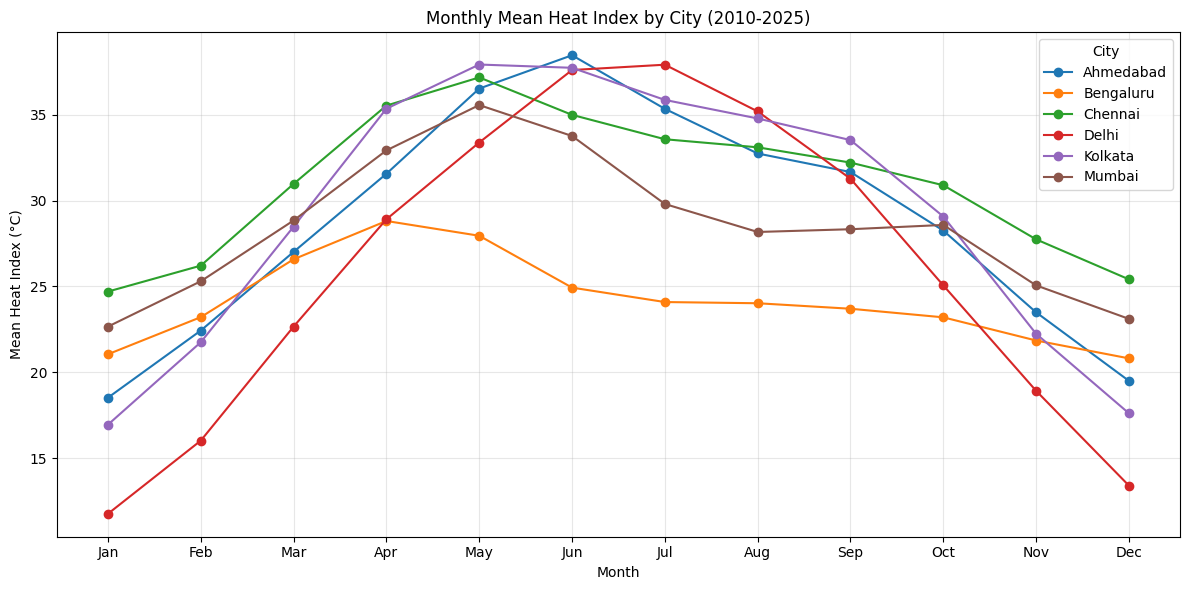

In [37]:
monthly_heatmap.T.plot(
    figsize=(12, 6),
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Mean Heat Index (°C)")
plt.title("Monthly Mean Heat Index by City (2010-2025)")
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
plt.legend(title="City")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

*Figure note:* This chart shows the monthly cycle of mean Heat Index by city; peak months and seasons are reported in the tables above.


## 10. Final city summary

Cities are ordered by the percentage of days in the Danger or Extreme Danger categories. This avoids penalizing cities with colder winters when comparing heat-stress exposure.


In [38]:
final_summary = pd.DataFrame({
    'Mean HI (°C)': city_summary['mean_hi'],
    'Max HI (°C)': city_summary['max_hi'],
    'Danger Days (%)': city_summary['danger_pct'],
    'Peak Month': peak_months_df['Peak Month'],
    'Peak Month HI (°C)': peak_months_df['Mean Heat Index (°C)'],
    'Peak Season': peak_season,
    'Peak Season HI (°C)': peak_season_hi
}).loc[city_summary.index].round(2)

final_summary


,Mean HI (°C),Max HI (°C),Danger Days (%),Peak Month,Peak Month HI (°C),Peak Season,Peak Season HI (°C)
city,,,,,,,
Kolkata,29.30,45.85,5.73,May,37.92,Summer,34.84
Delhi,26.05,44.23,4.48,July,37.91,Monsoon,34.83
Ahmedabad,28.81,43.05,3.97,June,38.46,Summer,33.36
Chennai,31.06,42.79,1.30,May,37.17,Summer,34.66
Mumbai,28.51,41.87,0.17,May,35.56,Summer,32.76
Bengaluru,24.18,33.60,0.00,April,28.81,Summer,27.07


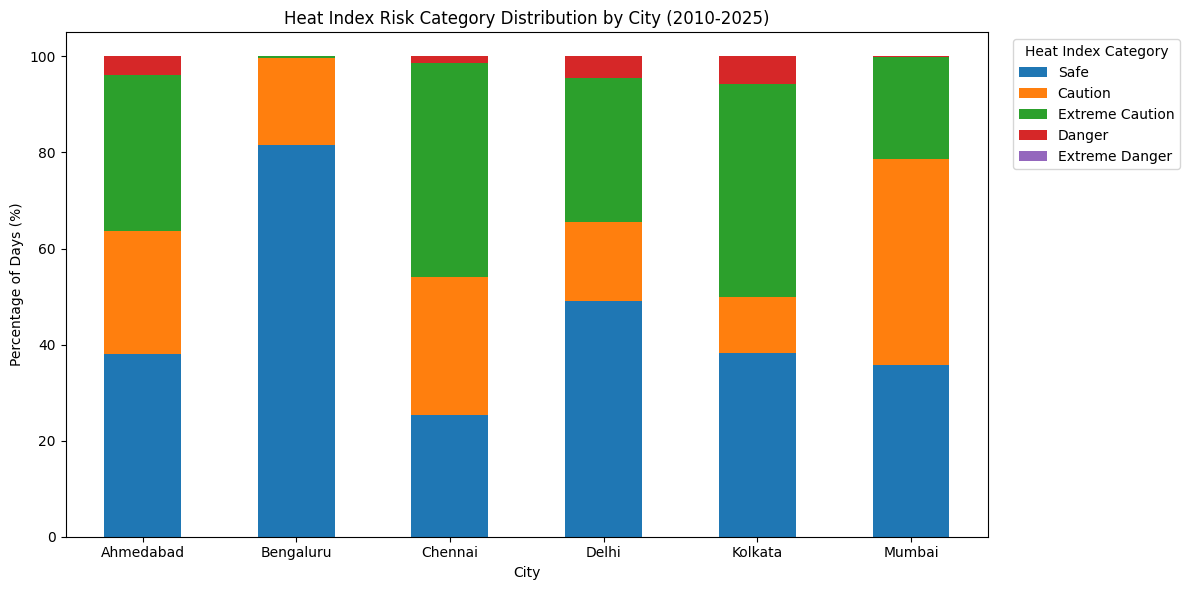

In [39]:
category_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.xlabel("City")
plt.ylabel("Percentage of Days (%)")
plt.title("Heat Index Risk Category Distribution by City (2010-2025)")
plt.legend(title="Heat Index Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

*Figure note:* The stacked bars show the full Heat Index category mix behind the danger-day ranking.


## 11. Export cleaned dataset

The cleaned daily dataset, including the Heat Index and risk category for each day, is saved for reuse.

In [40]:
df.to_csv("../dataset/cleaned_dataset.csv", index=False)

## Key findings

- **Kolkata** has the highest Danger-day share at **5.72%**, followed by Delhi (4.48%) and Ahmedabad (3.95%). Mumbai (0.17%) and Bengaluru (0%) have almost none.
- The temperature-only hot-day ranking is led by **Ahmedabad** (20.74% of days with max ≥ 40°C), while the humidity-adjusted Danger-day ranking is led by **Kolkata**.
- **Peak Heat Index months:** Kolkata: May (37.92°C); Delhi: July (37.91°C); Ahmedabad: June (38.46°C); Chennai: May (37.17°C); Mumbai: May (35.56°C); Bengaluru: April (28.81°C).
- Annual mean Heat Index shows **no statistically significant trend** during 2010-2025 in any of the 6 cities (p ≥ 0.05).
- Hot-day counts show **no statistically significant trend** in any of the 6 cities (p ≥ 0.05).

## Interpretation

- **Temperature alone misranks heat risk.** Ahmedabad leads on hot days (20.7% of days with max ≥ 40°C) but is only third on Danger days (3.95%). Kolkata is fourth on hot days (5.2%) but first on Danger days (5.72%), because humidity drives its heat stress.
- **Chennai** has almost no 40°C days (0.56%) yet the highest mean Heat Index (31.06°C), and about 75% of its days fall above the Safe category. Its stress is constant rather than peaky.
- **Delhi** has two distinct heat seasons: dry heat in May-June and humid heat in July. Its Heat Index peaks in July, and the Danger share is higher in the monsoon (10.05%) than in summer (5.84%).
- **Bengaluru** works as a control: 81.6% Safe days and no Danger days.
- Wet-bulb temperature agrees with the Heat Index (correlation 0.89), and Chennai ranks highest on both, which supports the humidity-adjusted approach.
- **No city shows a statistically significant trend** in annual Heat Index or hot days. Chennai's slope is closest (+0.039°C/year, p = 0.081), so the data does not confirm rising heat in this period.

## Innovation and contribution

- **Humidity-adjusted risk instead of temperature alone.** Cities are ranked by the share of Danger-level Heat Index days, not by air temperature. This changes the picture: Kolkata is 4th by hot days (5.2%) but 1st by Danger days (5.72%), while Ahmedabad leads on hot days (20.7%) but ranks 3rd on Danger days.
- **Standards-correct Heat Index implementation.** The NWS Rothfusz regression is applied only where it is valid, with its low- and high-humidity adjustments restricted to their proper ranges. Naive implementations overstate heat on dry and cool days.
- **Independent validation.** Heat Index results are cross-checked against wet-bulb temperature (correlation 0.89), and Chennai ranks highest on both.
- **Fair ranking metric.** Danger-day share avoids penalizing cities with cold winters, which a mean annual Heat Index does.
- **Climate-diverse design.** Hot-dry, hot-humid and moderate cities (including Bengaluru as a control) show how the same temperature carries different risk.
- **Honest statistics.** Trend tests (2010-2025) report no significant change, rather than overstating a rising-heat story.

## Limitations

- NASA POWER/MERRA-2 values are gridded model estimates, not station readings, and may understate local urban heat and peak maximums.
- The Heat Index uses daily mean temperature and humidity, so it misses within-day peaks, solar radiation, wind, acclimatization, and exposure duration.
- Hot days are a temperature threshold, not a duration-based heatwave definition.
- Season boundaries are a simplification, and the 16-year period is short for climate-trend conclusions.